# pyDANT Demo

About 12 minutes to run the demo.

pyDANT End-to-End Demo: An automated Colab walkthrough that downloads an example dataset, installs dependencies, configures parameters, executes the complete pyDANT neuron tracking pipeline, and visualizes the final results.

## Import Libraries

In [1]:
import requests
import os
from tqdm import tqdm
import numpy as np
import shutil
from IPython.display import Image, display

## Download Example Dataset

In [ ]:
# Download the dataset at https://figshare.com/articles/dataset/Example_Dataset_for_DANT/30596258
figshare_url = r"https://figshare.com/ndownloader/files/59490728"
save_dir="/content/"

# Create a session to simulate a real browser
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5',
    'Referer': 'https://figshare.com/'
})

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "Data_pyDANT.zip")

print("Starting download...")
print(f"Target: {save_path}\n")

with session.get(
    figshare_url,
    stream=True,
    allow_redirects=True,
    timeout=120
) as response:
    response.raise_for_status()

    # Display final URL
    print(f"Final URL: {response.url[:100]}...")

    # Get file information
    total_size = int(response.headers.get('content-length', 0))
    content_type = response.headers.get('content-type', 'unknown')

    print(f"Content-Type: {content_type}")
    print(f"Size: {total_size / (1024*1024):.2f} MB\n")

    # If HTML is returned and it's small, it's likely not the file we want
    if 'html' in content_type.lower() and total_size < 50000:
        print("❌ The response is a webpage, not a file.")
        print(f"Content preview:\n{response.text[:300]}")
        raise Exception("Failed to retrieve file download link.")

    # Start downloading
    print("Downloading...")
    with open(save_path, 'wb') as f, tqdm(
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024
    ) as bar:
        for chunk in response.iter_content(chunk_size=32768):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))

# Validation
actual_size = os.path.getsize(save_path)
print(f"\n{'='*60}")
if actual_size > 100000:
    print(f"✅ Success! File size: {actual_size/(1024*1024):.2f} MB")
else:
    print(f"❌ Failed! File is only {actual_size} bytes.")
print(f"Location: {save_path}")
print(f"{'='*60}")

## Download Example Dataset

In [2]:
# Define the Figshare URL and download the dataset
figshare_url = r"https://figshare.com/ndownloader/files/59490728"
save_dir="/content/"

Starting download...
Target: /content/Data_pyDANT.zip

Final URL: https://s3-eu-west-1.amazonaws.com/pfigshare-u-files/59490728/Data_pyDANT.zip?X-Amz-Algorithm=AWS4-H...
Content-Type: application/zip
Size: 1991.06 MB

Downloading...


100%|██████████| 1.94G/1.94G [01:40<00:00, 20.8MiB/s]


✅ Success! File size: 1991.06 MB
Location: /content/Data_pyDANT.zip


## Extract Dataset

In [3]:
# Unzip the downloaded dataset to the content directory
!unzip -q /content/Data_pyDANT.zip -d /content/

## Install pyDANT Package

In [4]:
# Install the pyDANT library
!pip install pyDANT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.2 MB/s eta 0:00:00


## Import Core Modules

In [5]:
# Import necessary libraries
from pyDANT import preprocess, motionEstimation, finalClustering, autoCuration
import hjson
import time
import numpy as np
import os

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Configure User Settings & Paths

In [6]:
# Load the settings configuration
path_settings = r"/content/Data_pyDANT/settings.json"

with open(path_settings, 'r') as f:
    user_settings = hjson.load(f)

# Update paths to match the Colab environment
user_settings['path_to_data'] = r"/content/Data_pyDANT/Data/"
user_settings['output_folder'] = r"/content/Data_pyDANT/DANT_Output/"

## Run Full Pipeline & Record Execution Time

In [7]:
# Start the timer
time_start = time.time()

# Run the pyDANT pipeline steps
preprocess(user_settings)       # Preprocessing
motionEstimation(user_settings) # Drift/Motion Estimation
finalClustering(user_settings)  # Clustering
autoCuration(user_settings)     # Automated Curation

# Calculate and save the total run time
run_time_sec = time.time() - time_start
print(f"Total run time: {run_time_sec:.2f} seconds")
np.save(os.path.join(user_settings['output_folder'], 'RunTimeSec.npy'), run_time_sec)

Loading data...
The output will be saved to /content/Data_pyDANT/DANT_Output/!
18 sessions found!


100%|██████████| 3479/3479 [02:15<00:00, 25.74it/s]


Saving to /content/Data_pyDANT/DANT_Output/...
Done!


/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:154: RuntimeWarning: divide by zero encountered in arctanh
  AutoCorr_similarity_matrix = np.atanh(AutoCorr_similarity_matrix)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:163: RuntimeWarning: divide by zero encountered in arctanh
  PETH_similarity_matrix = np.atanh(PETH_similarity_matrix)


Computing similarity done!
Iteration 1 starts!
Weights:
AutoCorr   PETH
[0.30352953 0.69647047]
Iteration 2 starts!
Weights:
AutoCorr   PETH
[0.2911972 0.7088028]
Iteration 3 starts!
Weights:
AutoCorr   PETH
[0.28825973 0.71174027]
Iteration 4 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 5 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 6 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 7 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 8 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 9 starts!
Weights:
AutoCorr   PETH
[0.28784111 0.71215889]
Iteration 10 starts!
8520 pairs of units are included for drift estimation!


...

The range of motion: [-21.7 μm ~ 17.6 μm]



Computing waveform similarity:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:98: RuntimeWarning: divide by zero encountered in arctanh
  temp = np.atanh(temp)
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:98: RuntimeWarning: invalid value encountered in arctanh
  temp = np.atanh(temp)
Computing waveform similarity: 100%|██████████| 125/125 [00:28<00:00,  4.32it/s]
/usr/local/lib/python3.12/dist-packages/pyDANT/IterativeClustering.py:154: RuntimeWarning: divide by zero encountered in arctanh
  AutoCorr_similarity_matrix = np.atanh(AutoCorr_similarity_matrix)


Computing similarity done!
Iteration 1 starts!
Weights:
Waveform   AutoCorr
[0.82913998 0.17086002]
Iteration 2 starts!
Weights:
Waveform   AutoCorr
[0.842179 0.157821]
Iteration 3 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 4 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 5 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 6 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 7 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 8 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 9 starts!
Weights:
Waveform   AutoCorr
[0.84220129 0.15779871]
Iteration 10 starts!
355 clusters and 21002 pairs before removing bad units!
91 deleting steps are done!
344 clusters and 20323 pairs after removing bad units!
DANT done! Output saved to /content/Data_pyDANT/DANT_Output/Output.npz
Found 344 clusters and 20323 matches from 3479 units during 18 sessions!


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Total run time: 652.35 seconds


## Display Output Figures  
If the process completes successfully, the output figures will be saved in `/content/Data_pyDANT/DANT_Output/Figures/`.


Motion across sessions:


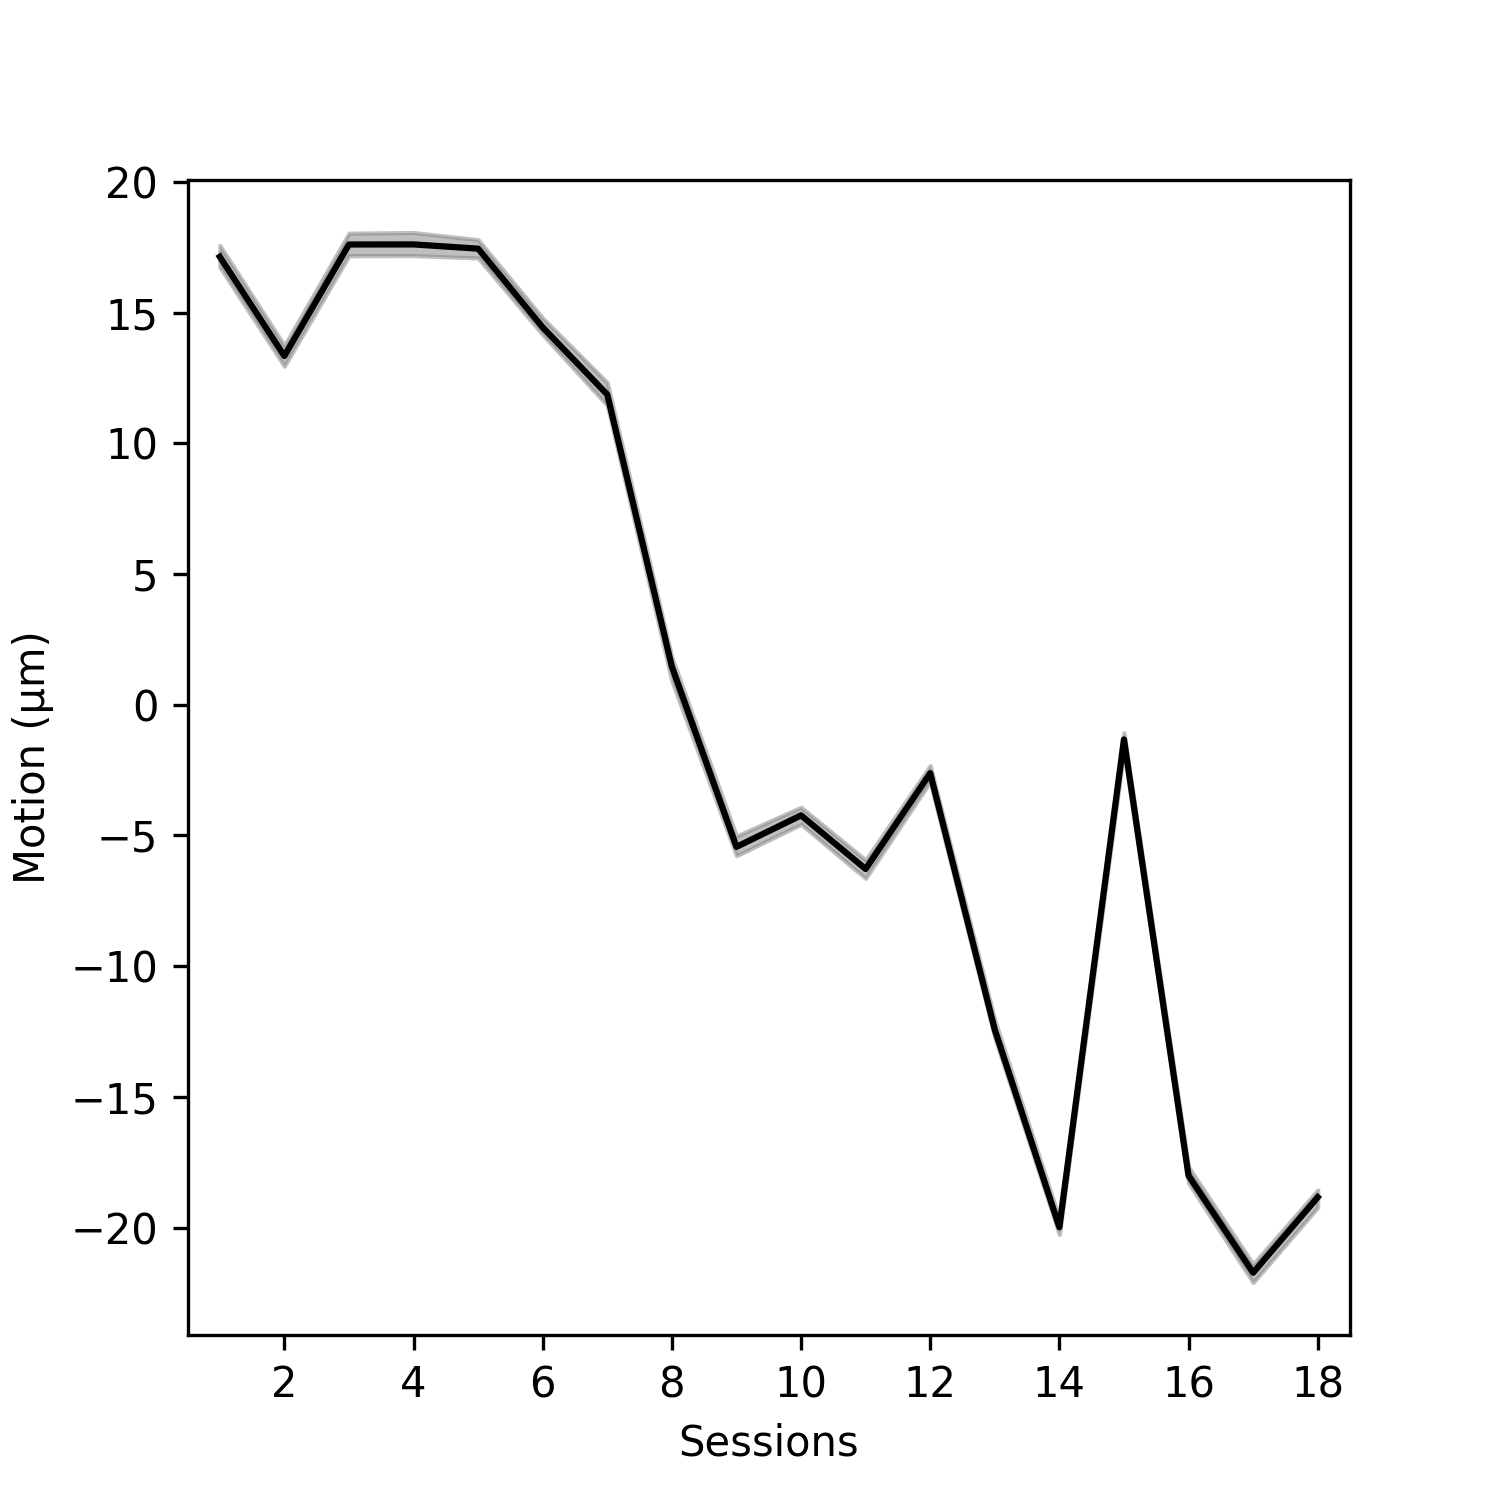


Matching probability:


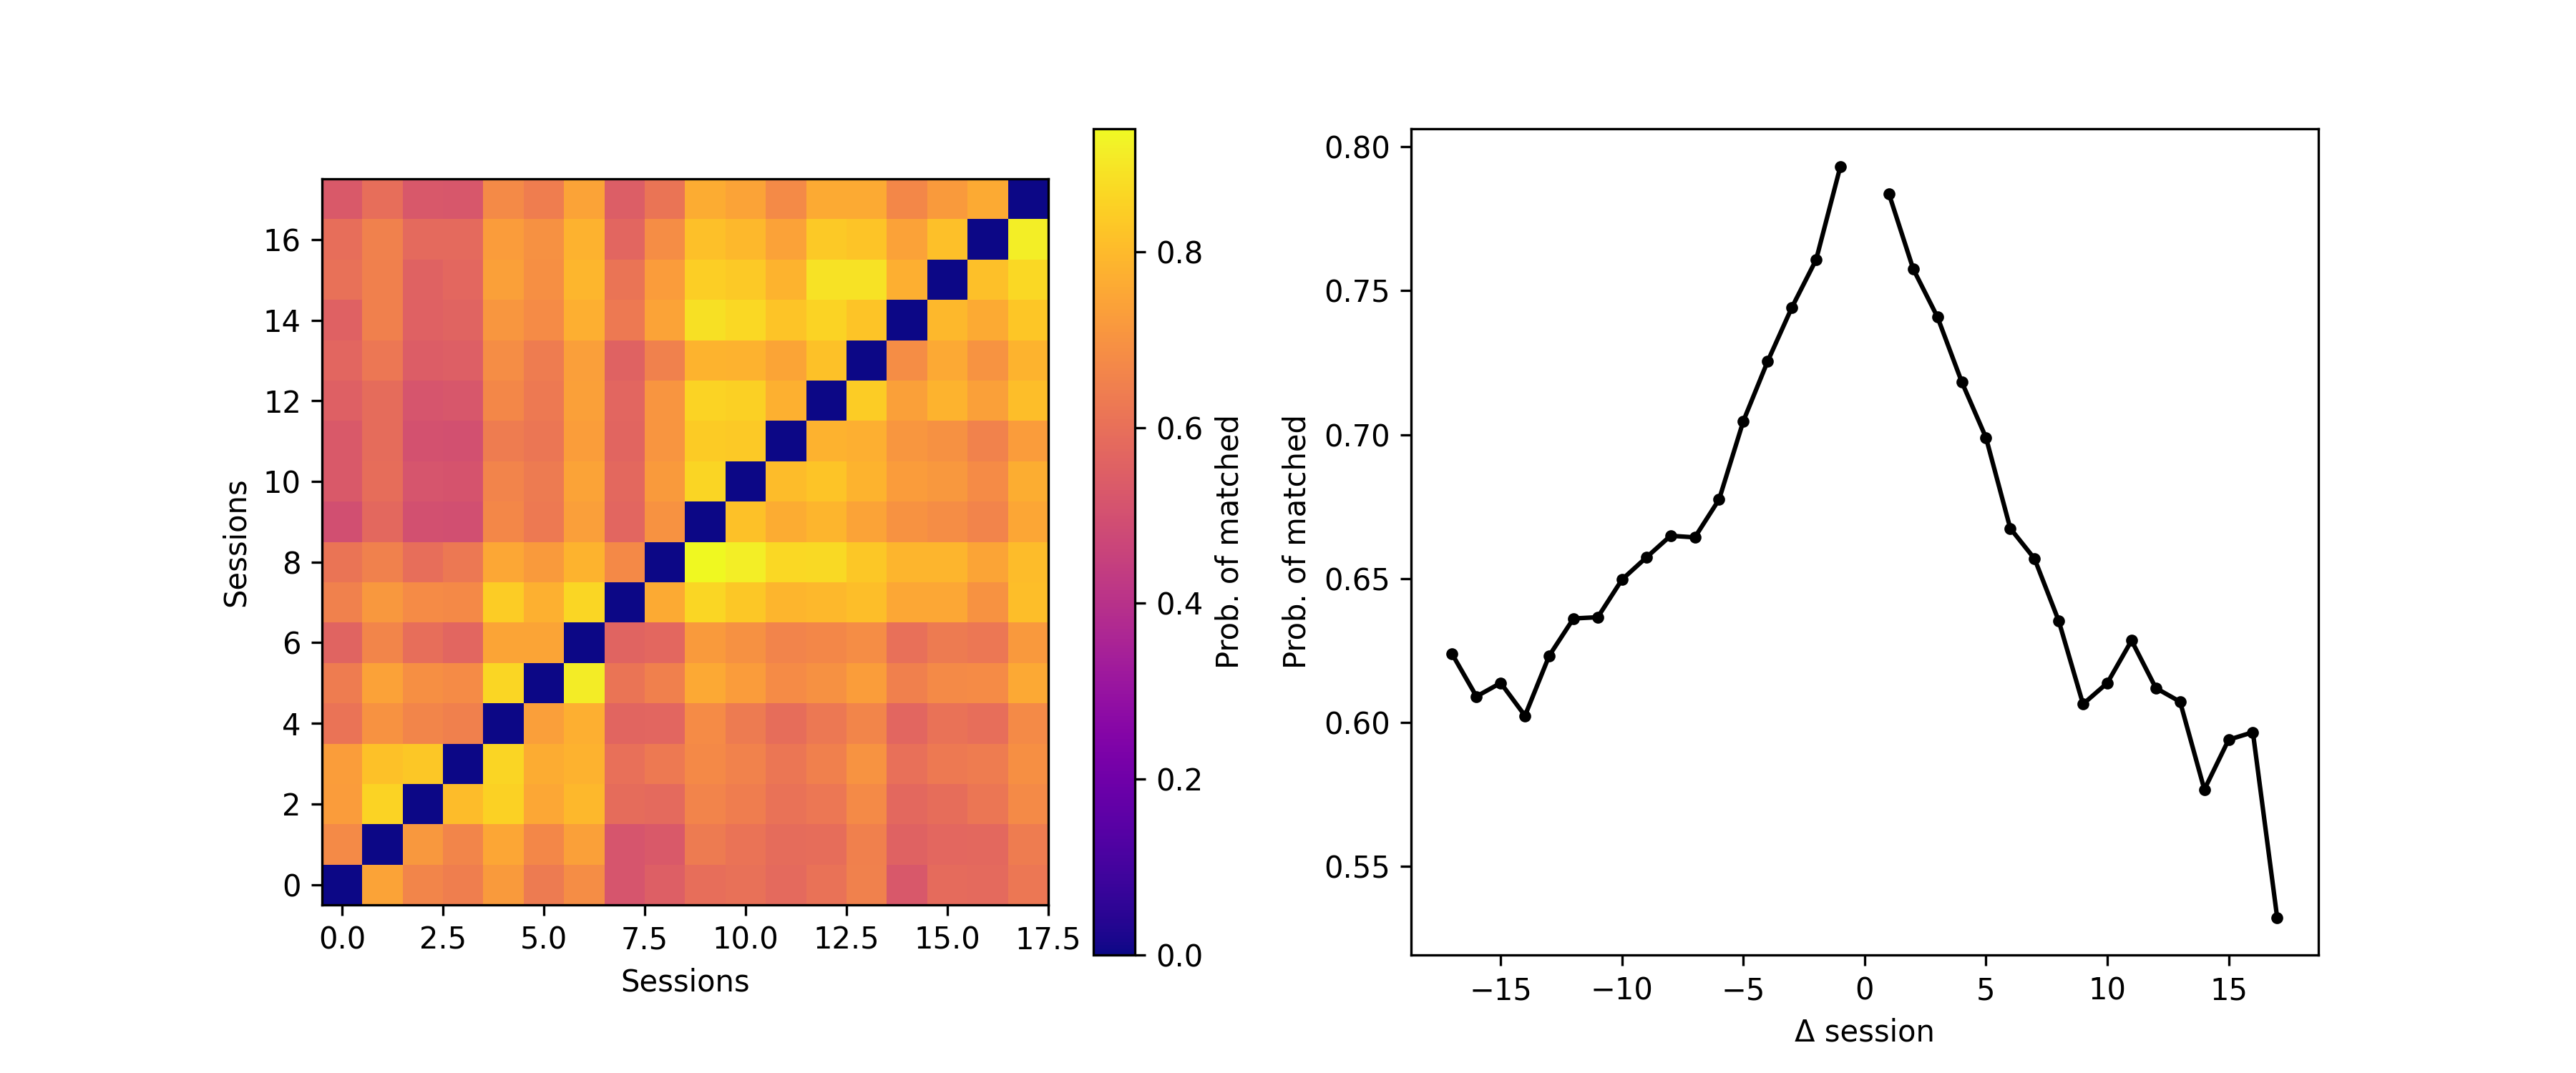

In [11]:
# Display the Motion estimation across sessions
print("Motion across sessions:")
display(Image('/content/Data_pyDANT/DANT_Output/Figures/Motion.png', width=300))

# Display the Matching probability figure
print("\nMatching probability:")
display(Image('/content/Data_pyDANT/DANT_Output/Figures/MatchedProbability.png', width=800))